In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = pd.read_csv(r"C:\Users\Sugavaneswara\Downloads\archive (3)\Taxi_Set.csv")
data

,trip_duration_sec,trip_duration_min,trip_duration_hr,distance_traveled_Km,KPH,wait_time_cost,distance_cost,fare_w_flag,tip,miscellaneous_fees,total_fare_new,num_of_passengers,surge_applied
0,748,12.47,0.207833,2.75,13.231756,4.97,4.27,11.94,24,6.30,42.24,1,False
1,1187,19.78,0.329667,3.43,10.404449,7.89,5.33,15.92,24,13.20,53.12,1,False
2,730,12.17,0.202833,3.12,15.382087,4.85,4.85,12.40,0,26.63,39.03,1,True
3,671,11.18,0.186333,5.63,30.214669,4.46,8.75,15.91,0,9.75,25.66,3,False
4,329,5.48,0.091300,2.09,22.883212,2.19,3.25,8.14,12,13.20,33.34,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
207591,1617,26.95,0.449167,8.42,18.745826,10.75,13.08,26.53,47,5.80,79.33,1,False
207592,438,7.30,0.121667,1.29,10.602740,2.91,2.00,7.61,12,34.58,54.19,1,True
207593,571,9.52,0.158667,2.82,17.773109,3.80,4.38,10.88,0,6.00,16.88,1,False
207594,491,8.18,0.136333,2.16,15.843521,3.26,3.36,9.32,0,13.50,22.82,1,False


In [68]:
data.isnull().sum()

trip_duration_sec       0
trip_duration_min       0
trip_duration_hr        0
distance_traveled_Km    0
KPH                     0
wait_time_cost          0
distance_cost           0
fare_w_flag             0
tip                     0
miscellaneous_fees      0
total_fare_new          0
num_of_passengers       0
surge_applied           0
dtype: int64

In [69]:
data.dropna(inplace=True)     

In [109]:
x = data[['distance_traveled_Km']].iloc[:201]
x

,distance_traveled_Km
0,2.75
1,3.43
2,3.12
3,5.63
4,2.09
...,...
196,15.51
197,2.08
198,1.24
199,0.80


In [110]:
y = data['total_fare_new'].iloc[:201]
y

0      42.24
1      53.12
2      39.03
3      25.66
4      33.34
       ...  
196    57.03
197    27.84
198    31.51
199    19.67
200    25.71
Name: total_fare_new, Length: 201, dtype: float64

In [111]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [112]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [113]:
y_pred = model.predict(x_test)
accuracy = r2_score(y_test,y_pred)
print("Accuracy : ",accuracy * 100)

Accuracy :  69.74493385417429


In [114]:
Distance = int(input("Enter the distance: "))
X = [[Distance]]
print("Fare:", model.predict(X))

Enter the distance:  35


Fare: [181.06550241]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


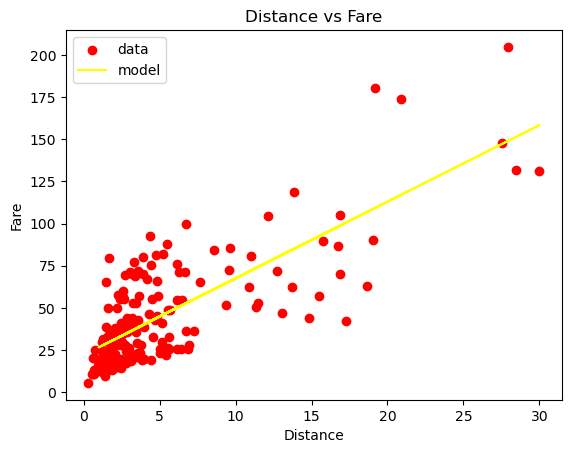

In [117]:
plt.scatter(x,y,color="red",label="data")
plt.plot(x_test,y_pred,color="yellow",label="model")
plt.title("Distance vs Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.legend()
plt.show()